# EE446 TinyML Lab 9: ASL Gesture Recognition

In this lab, you will train a small neural network using Arduino IMU gesture data, convert the trained model to TensorFlow Lite, and export a C header file for Arduino deployment.

The notebook is designed for the `tinyml-arduino` Python environment used in EE446.


## 1. Environment

Before running this notebook:

1. Activate the `tinyml-arduino` environment.
2. Start JupyterLab from that environment.
3. Select the kernel named `Python (tinyml-arduino)`.
4. Place the gesture CSV files in the same folder as this notebook.

This notebook does not install packages. It assumes the course environment has already been created.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"Working directory: {Path.cwd()}")

DATA_DIR = Path(".")
BUILD_DIR = Path("build")
BUILD_DIR.mkdir(exist_ok=True)


TensorFlow version: 2.14.1
Working directory: /Users/adityabhagwani/ai/projects/tinyml-arduino


## 2. Data Files

Place one CSV file per gesture in the notebook folder. Each file name must match the gesture name.

Expected files for this version:

- `hi.csv`
- `sup.csv`

Each CSV file must contain the following columns: `aX`, `aY`, `aZ`, `gX`, `gY`, `gZ`.


In [3]:
GESTURES = [
    "hi",
    "sup",
]

SAMPLES_PER_GESTURE = 119
REQUIRED_COLUMNS = ["aX", "aY", "aZ", "gX", "gY", "gZ"]

missing_files = [DATA_DIR / f"{gesture}.csv" for gesture in GESTURES if not (DATA_DIR / f"{gesture}.csv").exists()]
if missing_files:
    missing = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(
        "Missing gesture CSV file(s). Place the following file(s) in the notebook folder:\n"
        + missing
    )

print("Found gesture files:")
for gesture in GESTURES:
    print(f"  - {gesture}.csv")


Found gesture files:
  - hi.csv
  - sup.csv


## 3. Inspect One Gesture File

Use this plot to quickly check whether the accelerometer and gyroscope signals look reasonable before training.


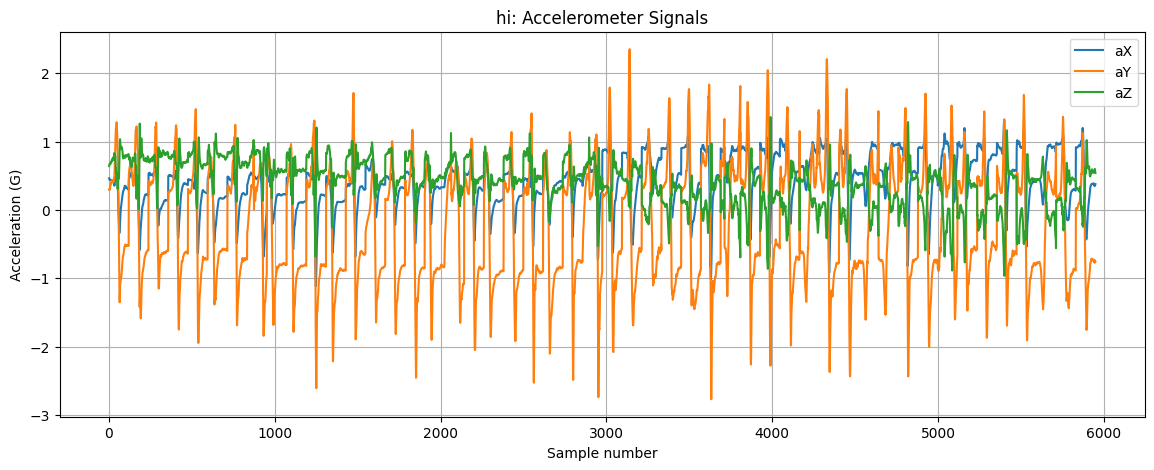

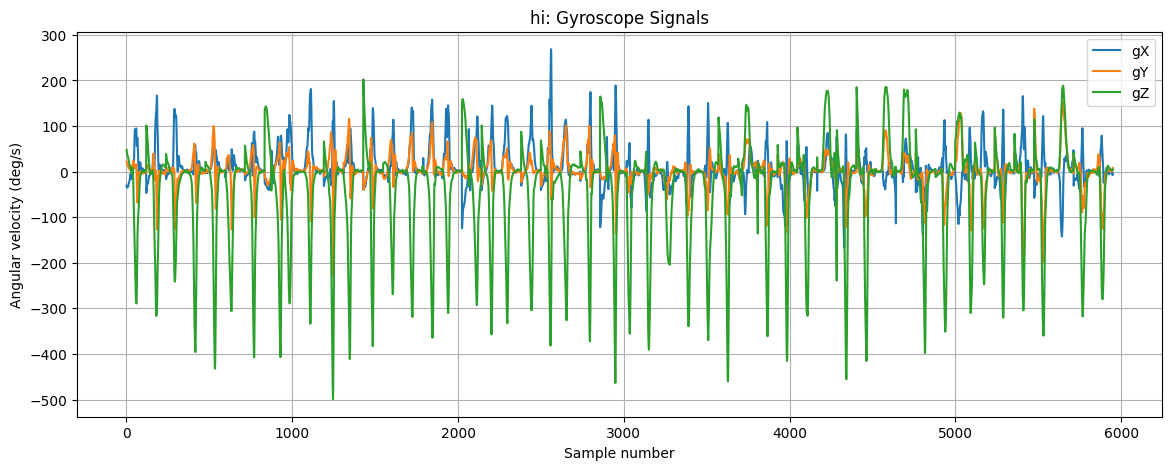

In [4]:
def plot_gesture_file(gesture_name: str) -> None:
    csv_path = DATA_DIR / f"{gesture_name}.csv"
    df = pd.read_csv(csv_path)

    missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_columns:
        raise ValueError(f"{csv_path} is missing required column(s): {missing_columns}")

    sample_index = np.arange(1, len(df) + 1)

    plt.figure(figsize=(14, 5))
    plt.plot(sample_index, df["aX"], label="aX")
    plt.plot(sample_index, df["aY"], label="aY")
    plt.plot(sample_index, df["aZ"], label="aZ")
    plt.title(f"{gesture_name}: Accelerometer Signals")
    plt.xlabel("Sample number")
    plt.ylabel("Acceleration (G)")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(sample_index, df["gX"], label="gX")
    plt.plot(sample_index, df["gY"], label="gY")
    plt.plot(sample_index, df["gZ"], label="gZ")
    plt.title(f"{gesture_name}: Gyroscope Signals")
    plt.xlabel("Sample number")
    plt.ylabel("Angular velocity (deg/s)")
    plt.legend()
    plt.grid(True)
    plt.show()


GESTURE_TO_PREVIEW = GESTURES[0]
plot_gesture_file(GESTURE_TO_PREVIEW)


## 4. Parse and Prepare the Dataset

The next cell converts each gesture recording into one input vector. Each recording contains `SAMPLES_PER_GESTURE` time steps, and each time step has six IMU values.

The output label is one-hot encoded because the model predicts one gesture class.


In [5]:
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

NUM_GESTURES = len(GESTURES)
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES, dtype=np.float32)

inputs = []
outputs = []

for gesture_index, gesture in enumerate(GESTURES):
    csv_path = DATA_DIR / f"{gesture}.csv"
    df = pd.read_csv(csv_path)

    missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_columns:
        raise ValueError(f"{csv_path} is missing required column(s): {missing_columns}")

    num_recordings = len(df) // SAMPLES_PER_GESTURE
    if num_recordings == 0:
        raise ValueError(f"{csv_path} does not contain enough samples for one full gesture recording.")

    print(f"{gesture}: {num_recordings} recording(s)")

    output = ONE_HOT_ENCODED_GESTURES[gesture_index]

    for recording_index in range(num_recordings):
        start = recording_index * SAMPLES_PER_GESTURE
        end = start + SAMPLES_PER_GESTURE
        recording = df.iloc[start:end]

        tensor = []
        for _, row in recording.iterrows():
            tensor.extend([
                (row["aX"] + 4.0) / 8.0,
                (row["aY"] + 4.0) / 8.0,
                (row["aZ"] + 4.0) / 8.0,
                (row["gX"] + 2000.0) / 4000.0,
                (row["gY"] + 2000.0) / 4000.0,
                (row["gZ"] + 2000.0) / 4000.0,
            ])

        inputs.append(tensor)
        outputs.append(output)

inputs = np.asarray(inputs, dtype=np.float32)
outputs = np.asarray(outputs, dtype=np.float32)

print(f"Input shape: {inputs.shape}")
print(f"Output shape: {outputs.shape}")


hi: 50 recording(s)
sup: 50 recording(s)
Input shape: (100, 714)
Output shape: (100, 2)


## 5. Randomize and Split the Dataset

The dataset is split into:

- 60% training data
- 20% validation data
- 20% test data


In [6]:
num_inputs = len(inputs)
if num_inputs < 5:
    raise ValueError("The dataset is very small. Collect more gesture recordings before training.")

random_order = np.arange(num_inputs)
np.random.shuffle(random_order)

inputs = inputs[random_order]
outputs = outputs[random_order]

train_split = int(0.6 * num_inputs)
test_split = int(0.8 * num_inputs)

inputs_train, inputs_validate, inputs_test = np.split(inputs, [train_split, test_split])
outputs_train, outputs_validate, outputs_test = np.split(outputs, [train_split, test_split])

print(f"Training samples:   {len(inputs_train)}")
print(f"Validation samples: {len(inputs_validate)}")
print(f"Test samples:       {len(inputs_test)}")


Training samples:   60
Validation samples: 20
Test samples:       20


## 6. Build and Train the Model

🔴 **Important: Read this carefully before running the next cell.**

The next cell provides the full model-building and training code. However, the training setup contains **one intentional issue** that must be corrected before you continue.

⚠️ **Your task is to carefully inspect the model architecture, output labels, loss function, optimizer, and evaluation metric.** Then revise the training setup so that it correctly matches the classification task.

🔴 **After fixing the issue, do not stop there.** Make sure the rest of the notebook is also consistent with your correction.

In particular, update any downstream:

- **plot titles**
- **axis labels**
- **history keys**
- **values passed to plotting code**

as needed.

✅ Your final implementation should be technically sound, complete, and consistent from model training through evaluation and visualization.

In [16]:
# Build the model and train it.
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(50, activation='relu'))  # ReLU is used for performance.
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax'))  # Softmax is used because only one gesture is expected per input.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=100,
    batch_size=16,
    validation_data=(inputs_validate, outputs_validate),
)

print("History keys:", list(history.history.keys()))


Epoch 1/100
4/4 [==============================] - 0s 27ms/step - loss: 0.7054 - accuracy: 0.4167 - val_loss: 0.6773 - val_accuracy: 0.7000
Epoch 2/100
4/4 [==============================] - 0s 5ms/step - loss: 0.6726 - accuracy: 0.6167 - val_loss: 0.6649 - val_accuracy: 0.5500
Epoch 3/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7097 - accuracy: 0.4833 - val_loss: 0.6363 - val_accuracy: 0.5500
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 0.6658 - accuracy: 0.5500 - val_loss: 0.7277 - val_accuracy: 0.4500
Epoch 5/100
4/4 [==============================] - 0s 6ms/step - loss: 0.6281 - accuracy: 0.5500 - val_loss: 0.6305 - val_accuracy: 0.7000
Epoch 6/100
4/4 [==============================] - 0s 5ms/step - loss: 0.5921 - accuracy: 0.9500 - val_loss: 0.6121 - val_accuracy: 0.8000
Epoch 7/100
4/4 [==============================] - 0s 6ms/step - loss: 0.5810 - accuracy: 0.9500 - val_loss: 0.6122 - val_accuracy: 0.7500
Epoch 8/100
4/4 [=========

## 7. Plot Training Progress

Use the training history to check whether the model is improving. If you changed the training setup above, make the corresponding updates below.


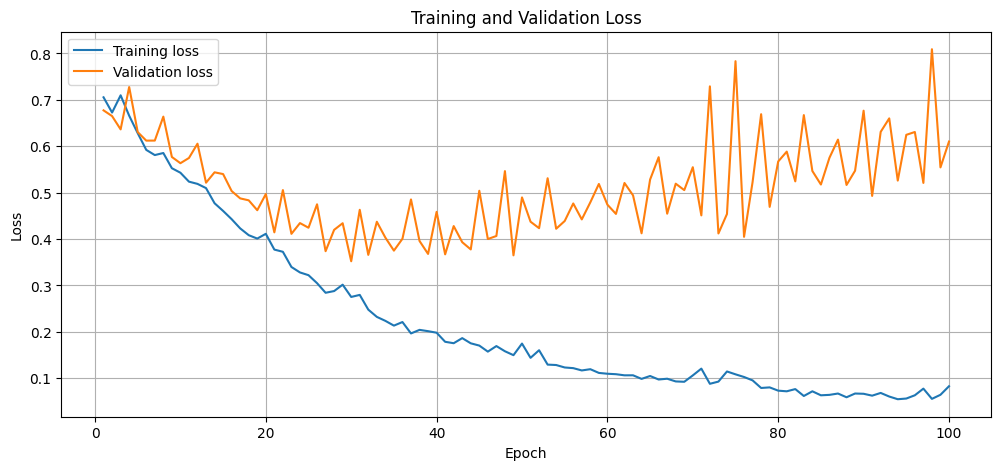

In [17]:
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = np.arange(1, len(loss) + 1)

plt.figure(figsize=(12, 5))
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


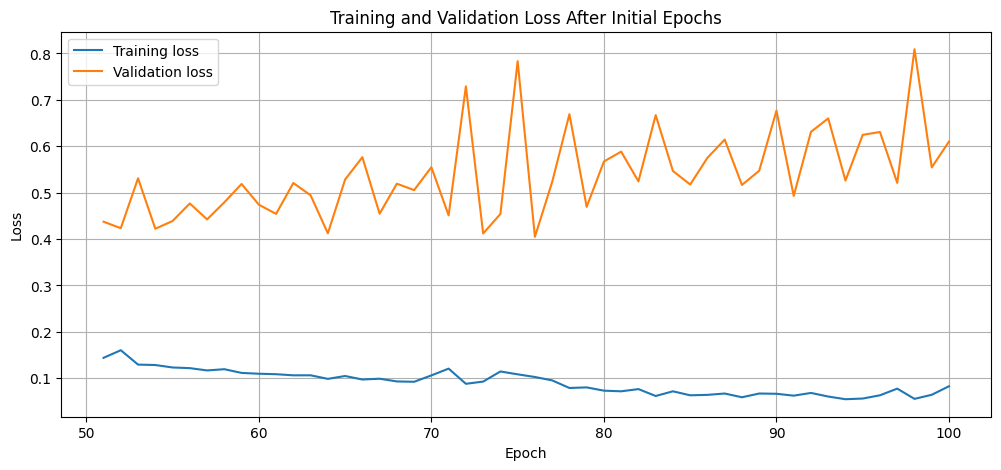

In [18]:
SKIP = 50

plt.figure(figsize=(12, 5))
plt.plot(epochs[SKIP:], loss[SKIP:], label="Training loss")
plt.plot(epochs[SKIP:], val_loss[SKIP:], label="Validation loss")
plt.title("Training and Validation Loss After Initial Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


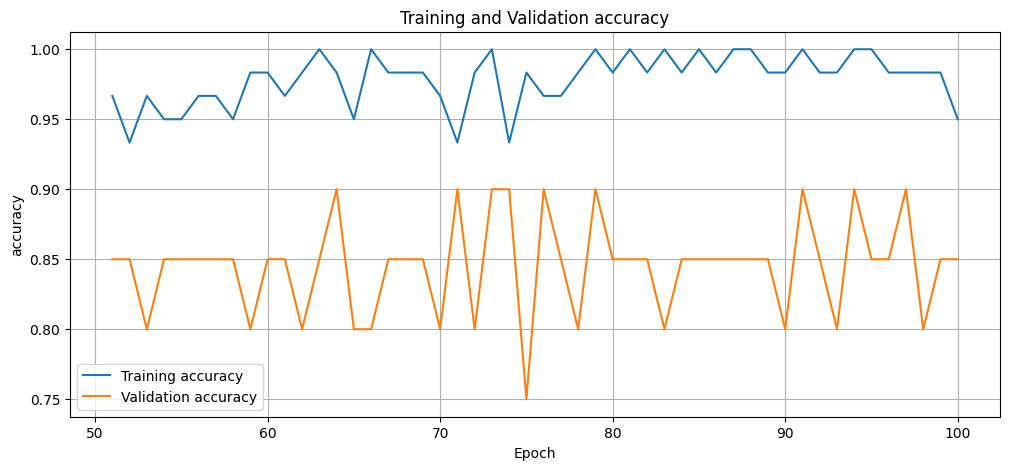

In [19]:
METRIC_TO_PLOT = "accuracy"  # Update this if you changed the metric used during training.
VAL_METRIC_TO_PLOT = f"val_{METRIC_TO_PLOT}"

metric_values = history.history[METRIC_TO_PLOT]
val_metric_values = history.history[VAL_METRIC_TO_PLOT]

plt.figure(figsize=(12, 5))
plt.plot(epochs[SKIP:], metric_values[SKIP:], label=f"Training {METRIC_TO_PLOT}")
plt.plot(epochs[SKIP:], val_metric_values[SKIP:], label=f"Validation {METRIC_TO_PLOT}")
plt.title(f"Training and Validation {METRIC_TO_PLOT}")
plt.xlabel("Epoch")
plt.ylabel(METRIC_TO_PLOT)
plt.legend()
plt.grid(True)
plt.show()


## 8. Evaluate with Test Data

Run the trained model on the held-out test set and compare the predicted gesture labels with the true labels.


In [20]:
test_results = model.evaluate(inputs_test, outputs_test, verbose=0)

print("Test results:")
for name, value in zip(model.metrics_names, test_results):
    print(f"  {name}: {value:.4f}")


Test results:
  loss: 0.0795
  accuracy: 1.0000


1/1 [==============================] - 0s 29ms/step
Predicted probabilities:
[[0.018 0.982]
 [0.749 0.251]
 [0.044 0.956]
 [0.998 0.002]
 [0.998 0.002]
 [0.998 0.002]
 [0.063 0.937]
 [0.004 0.996]
 [0.995 0.005]
 [0.862 0.138]
 [0.023 0.977]
 [0.049 0.951]
 [0.075 0.925]
 [0.214 0.786]
 [0.09  0.91 ]
 [0.067 0.933]
 [0.687 0.313]
 [0.059 0.941]
 [0.01  0.99 ]
 [0.995 0.005]]

Predicted labels:
['sup', 'hi', 'sup', 'hi', 'hi', 'hi', 'sup', 'sup', 'hi', 'hi', 'sup', 'sup', 'sup', 'sup', 'sup', 'sup', 'hi', 'sup', 'sup', 'hi']

Actual labels:
['sup', 'hi', 'sup', 'hi', 'hi', 'hi', 'sup', 'sup', 'hi', 'hi', 'sup', 'sup', 'sup', 'sup', 'sup', 'sup', 'hi', 'sup', 'sup', 'hi']


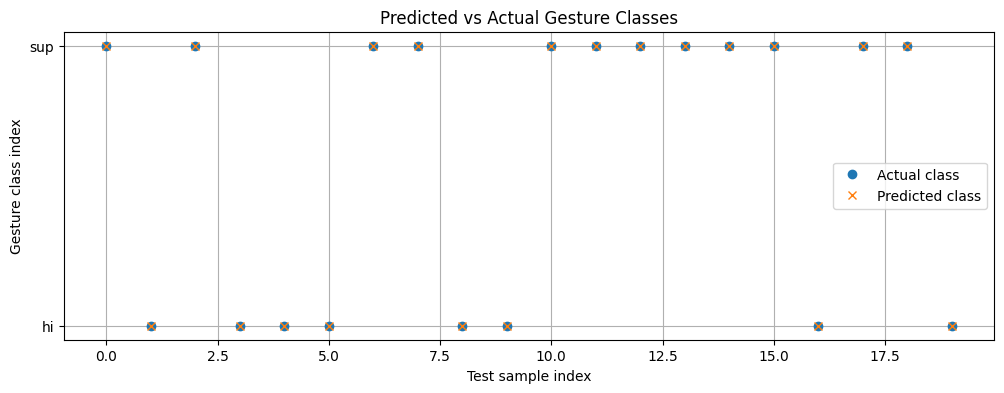

In [21]:
predictions = model.predict(inputs_test)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(outputs_test, axis=1)

print("Predicted probabilities:")
print(np.round(predictions, 3))

print("\nPredicted labels:")
print([GESTURES[index] for index in predicted_classes])

print("\nActual labels:")
print([GESTURES[index] for index in actual_classes])

plt.figure(figsize=(12, 4))
plt.plot(actual_classes, "o", label="Actual class")
plt.plot(predicted_classes, "x", label="Predicted class")
plt.title("Predicted vs Actual Gesture Classes")
plt.xlabel("Test sample index")
plt.ylabel("Gesture class index")
plt.yticks(range(NUM_GESTURES), GESTURES)
plt.legend()
plt.grid(True)
plt.show()


## 9. Convert the Model to TensorFlow Lite

The next cell converts the trained Keras model to `.tflite` format and saves it in the `build/` folder.


In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = BUILD_DIR / "gesture_model.tflite"
tflite_path.write_bytes(tflite_model)

print(f"Saved: {tflite_path}")
print(f"TFLite model size: {tflite_path.stat().st_size:,} bytes")


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpb35pfu5r/assets


INFO:tensorflow:Assets written to: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpb35pfu5r/assets


Saved: build/gesture_model.tflite
TFLite model size: 148,328 bytes


2026-06-07 20:35:55.263435: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-06-07 20:35:55.263736: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-06-07 20:35:55.264196: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpb35pfu5r
2026-06-07 20:35:55.264913: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-06-07 20:35:55.264919: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpb35pfu5r
2026-06-07 20:35:55.268235: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-06-07 20:35:55.300870: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/s5/ywgpwqpx3yq714sfgz4w0t3w0000gn/T/tmpb35pfu5r
2026-06-

## 10. Export the TensorFlow Lite Model as an Arduino Header

The next cell creates `build/model.h`. Add this file as a tab in your Arduino sketch.


In [23]:
def write_c_header(tflite_file: Path, header_file: Path, array_name: str = "model") -> None:
    model_bytes = tflite_file.read_bytes()

    lines = [
        "#pragma once",
        "",
        f"const unsigned char {array_name}[] = {{",
    ]

    for start in range(0, len(model_bytes), 12):
        chunk = model_bytes[start:start + 12]
        byte_values = ", ".join(f"0x{byte:02x}" for byte in chunk)
        lines.append(f"  {byte_values},")

    lines.extend([
        "};",
        f"const unsigned int {array_name}_len = {len(model_bytes)};",
        "",
    ])

    header_file.write_text("\n".join(lines), encoding="utf-8")


header_path = BUILD_DIR / "model.h"
write_c_header(tflite_path, header_path, array_name="model")

print(f"Saved: {header_path}")
print(f"Header file size: {header_path.stat().st_size:,} bytes")


Saved: build/model.h
Header file size: 914,778 bytes


## 11. Submission Reminder

Submit the completed notebook and the generated files from the `build/` folder as instructed on Canvas. Make sure the notebook output clearly shows that your final training, evaluation, TensorFlow Lite conversion, and header export steps ran successfully.
